# Maximum Entropy (MaxEnt) Periyar - Landslide

In [3]:
! pip install mlxtend

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [5]:
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Landslide_ML_CSV.csv"
df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'Elevation1', 'NDBI1', 'NDVI1', 'NDWI1', 'TRI1',
       'Slope1', 'PlaCurv1', 'SPI1', 'STI1', 'TPI1', 'WRI1', 'FlowDir1',
       'Rain1', 'Rain2', 'Rain3', 'Rain4', 'Rain5', 'Rain6', 'Rain7', 'Rain8',
       'Rain9', 'Rain10', 'Rain11', 'DisRoad1', 'DisStream1', 'LULC1',
       'Target_Var'],
      dtype='object')


In [7]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 3492
Total Columns: 29

First 5 Rows:
                                            wkt_geom     Aspect1  Elevation1  \
0  Point (77.17999999965347513 10.15999999987500857)  180.000000        1995   
1   Point (77.17079999973189786 10.0009999996577772)  153.082428        1103   
2   Point (77.17223500043203899 9.98379799987744576)  247.925995        1108   
3   Point (77.17254800014613636 9.98688699981090089)    4.148260        1073   
4   Point (77.17255500045526162 9.98667000001201188)    6.682299        1086   

      NDBI1     NDVI1     NDWI1       TRI1     Slope1  PlaCurv1         SPI1  \
0 -0.146512  0.316512 -0.298769   5.652488  12.769178  0.002572  25474.51172   
1 -0.087838  0.148579 -0.165812  17.478735  34.600918 -0.001880  38164.81250   
2 -0.122368  0.318481 -0.295356   8.010795  16.779390  0.001042  18591.56445   
3 -0.186393  0.331122 -0.301739  10.934146  24.439333 -0.004785  26223.40430   
4 -0.186393  0.331122 -0.301739  11.063230  22.965326 -0.000151  2494

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Step 1: Load Data and Prepare Target
target_column = "Target_Var"  # Replace with actual column name in your data

# Drop non-feature columns
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle dataset
df = df.fillna(0)  # Handle missing values

X = df.drop(columns=[target_column, "wkt_geom"], errors="ignore")
y = df[target_column]

# Step 2: Train-Test Split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=1, stratify=y)

# Step 3: Standardize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Hyperparameter Tuning using GridSearchCV
param_grid = {'C': [0.1, 1, 10]}  # Regularization strength (inverse of lambda)
grid = GridSearchCV(LogisticRegression(solver='lbfgs', max_iter=500),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best hyperparameters (GridSearchCV):", grid.best_params_)

# Step 5: Train Final Logistic Regression (MaxEnt) Model
best_model = LogisticRegression(solver='lbfgs', 
                                C=grid.best_params_['C'], 
                                max_iter=500)
best_model.fit(X_train, y_train)

# Step 6: Predict
y_pred = best_model.predict(X_test)

# Step 7: Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Step 8: Display Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)


Best hyperparameters (GridSearchCV): {'C': 10}
Accuracy: 0.8177
Precision: 0.7856
Recall: 0.8740

Confusion Matrix:
 [[399 125]
 [ 66 458]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.81       524
           1       0.79      0.87      0.83       524

    accuracy                           0.82      1048
   macro avg       0.82      0.82      0.82      1048
weighted avg       0.82      0.82      0.82      1048



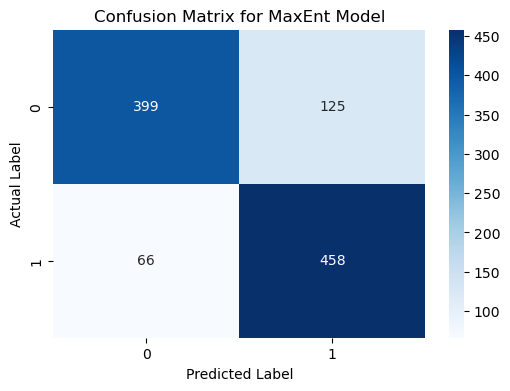

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for MaxEnt Model")
plt.show()


Best hyperparameters (GridSearchCV): {'C': 10}
Accuracy: 0.7939
Precision: 0.7790
Recall: 0.8206

Confusion Matrix:
 [[402 122]
 [ 94 430]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       524
           1       0.78      0.82      0.80       524

    accuracy                           0.79      1048
   macro avg       0.79      0.79      0.79      1048
weighted avg       0.79      0.79      0.79      1048



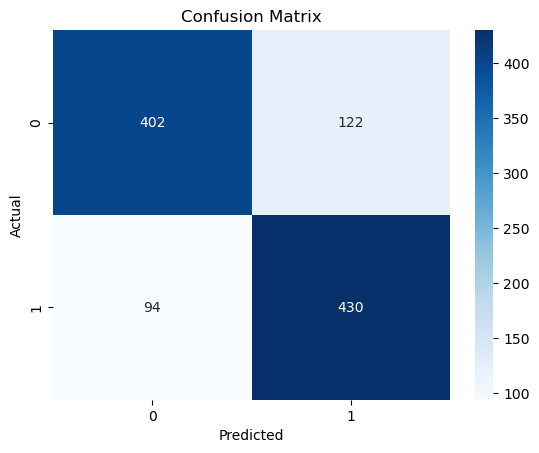

Class labels order: [0 1]
ROC AUC: 0.8649


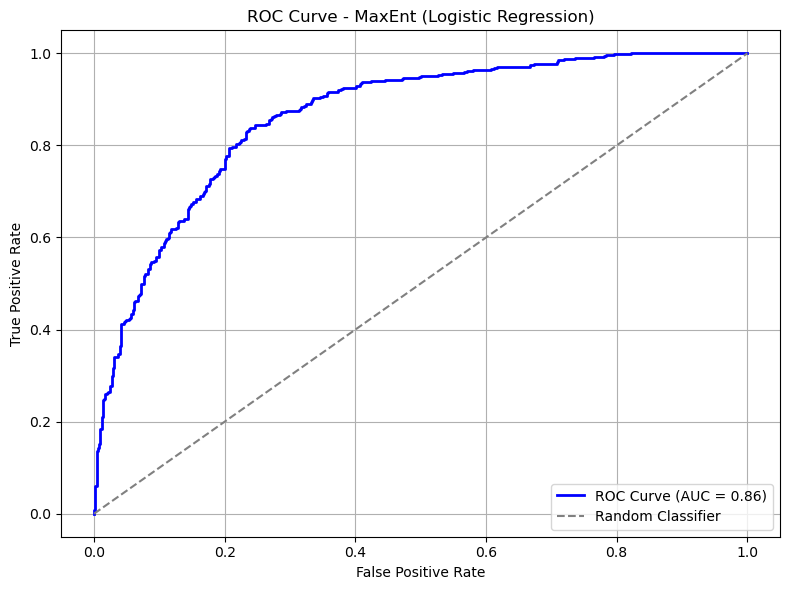

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare Data
target_column = "Target_Var"  # Replace with your actual target column

# Shuffle and clean
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.fillna(0)

# Define features and target
X = df.drop(columns=[target_column, "wkt_geom"], errors="ignore")
y = df[target_column]

# Step 2: Train-Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Step 3: Standardize Features (preserve column names to avoid warnings)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Step 4: Hyperparameter Tuning (MaxEnt = Logistic Regression)
param_grid = {'C': [0.1, 1, 10]}  # Inverse of regularization strength
grid = GridSearchCV(LogisticRegression(solver='lbfgs', max_iter=500),
                    param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best hyperparameters (GridSearchCV):", grid.best_params_)

# Step 5: Train Best Model
best_model = LogisticRegression(solver='lbfgs', 
                                C=grid.best_params_['C'], 
                                max_iter=500)
best_model.fit(X_train_scaled, y_train)

# Step 6: Predict
y_pred = best_model.predict(X_test_scaled)

# Step 7: Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print scores
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# Optional: Visualize Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 8: ROC Curve
print("Class labels order:", best_model.classes_)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MaxEnt (Logistic Regression)")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
import pandas as pd
df_maxent = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': y_probs,
    'Predicted_Label': y_pred
})

save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\MaxEnt_Landslide_Results.csv"
df_maxent.to_csv(save_path, index=False)


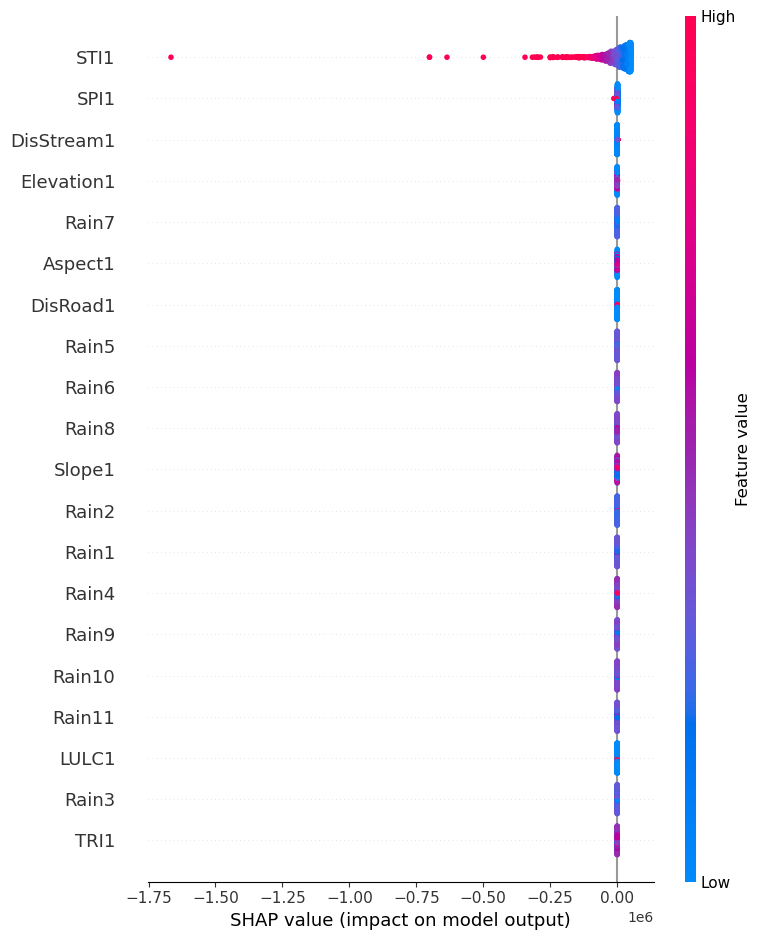

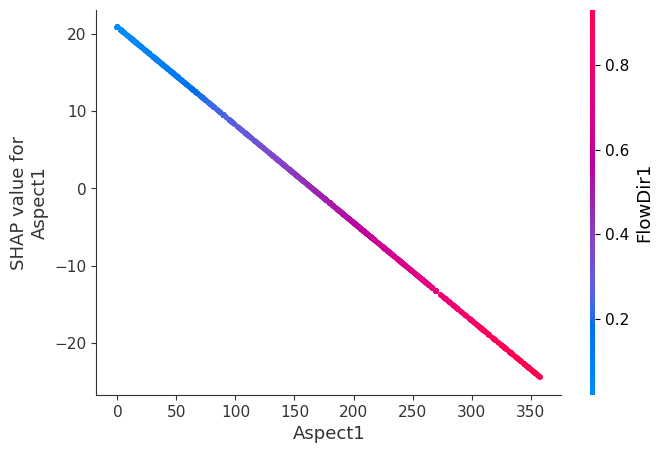

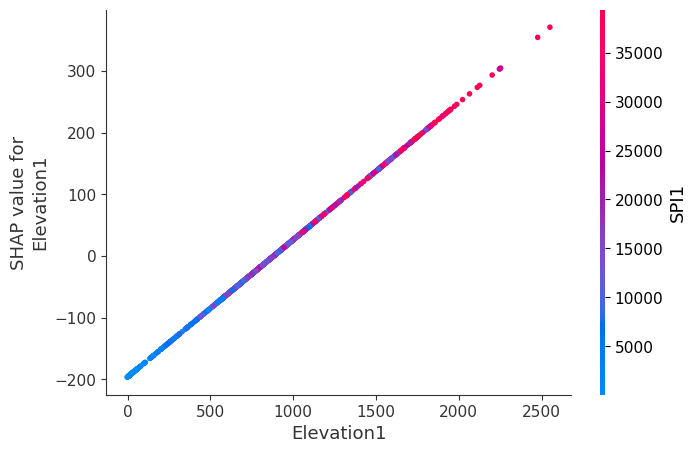

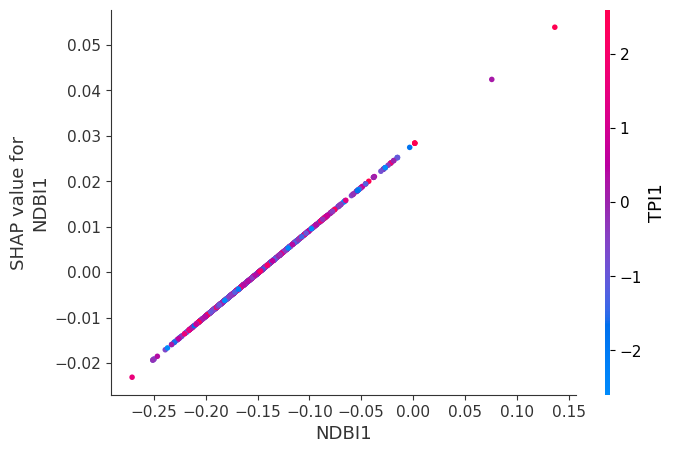

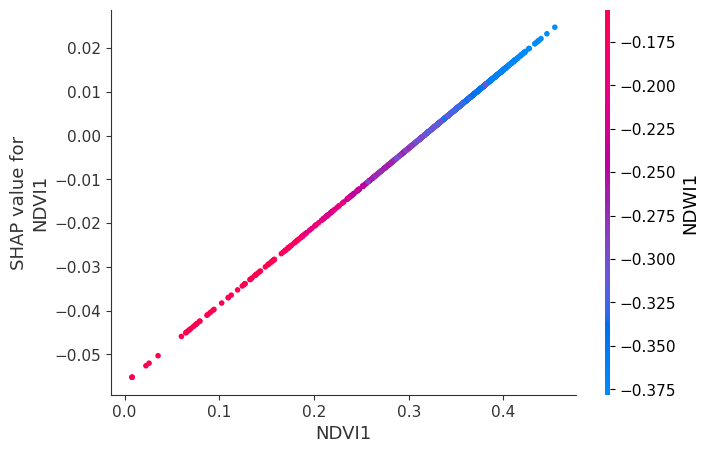

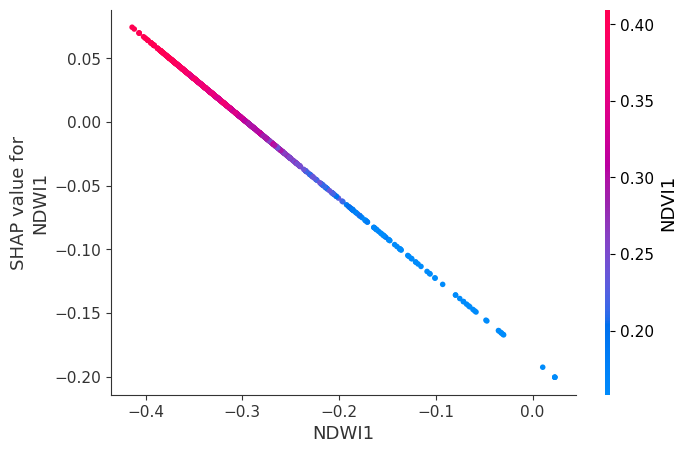


Feature Ranking based on SHAP Values:
       Feature  SHAP Importance
9         STI1     44187.357591
8         SPI1       813.637109
25  DisStream1        93.114936
1   Elevation1        82.303730
19       Rain7        11.546705
0      Aspect1        10.941387
24    DisRoad1         5.932357
17       Rain5         4.502110
18       Rain6         3.545909
20       Rain8         2.787689


In [31]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Retrieve feature names from the original X dataframe
feature_names = X.columns  # Get feature names before standardization

# **Step 7: SHAP Analysis for MaxEnt Model**
explainer = shap.LinearExplainer(best_model, X_train)  # Correct Explainer for Logistic Regression
shap_values = explainer.shap_values(X_test)  # Compute SHAP values

# **Step 8: SHAP Summary Plot (Global Feature Importance)**
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_names)  # Fix: Use original feature names

# **Step 9: SHAP Dependence Plots for Top Features**
for feature_idx in range(min(5, len(feature_names))):  # Limit to 5 features for efficiency
    shap.dependence_plot(feature_names[feature_idx], shap_values, X_test, feature_names=feature_names)

# **Step 10: Feature Ranking using SHAP Values**
shap_mean_contributions = np.abs(shap_values).mean(axis=0)  # Mean absolute SHAP values per feature
feature_ranking = pd.DataFrame({'Feature': feature_names, 'SHAP Importance': shap_mean_contributions})
feature_ranking = feature_ranking.sort_values(by="SHAP Importance", ascending=False)

print("\nFeature Ranking based on SHAP Values:")
print(feature_ranking.head(10))  # Show top 10 important features
